# Poisoned Models Probing Notebook
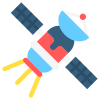

## Install Dependencies


In [8]:
!pip install --quiet torch==2.6.0 darts==0.33.0 scikit-learn==1.6.1 2>/dev/null

## Imports

In [9]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.models import NHiTSModel

# Suppress warnings and set figure size
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('fivethirtyeight')


## Data

In [10]:
# Read the cleaned training CSV into a DataFrame
train_data_df = pd.read_csv(
    "./data/clean_train_data.csv",
    index_col=0
)

# Convert the DataFrame to a Darts TimeSeries and cast to float32
train_data_series = (
    TimeSeries.from_dataframe(train_data_df)
    .astype(np.float32)
)

## Example Poisoned Model

In [11]:
model_number = 1
poisoned_model_path = (
    f"./data/poisoned_models/poisoned_model_{model_number}/poisoned_model.pt"
)
poisoned_model = NHiTSModel.load(poisoned_model_path)

## Sample Prediction

In [12]:
# Predict the next 400 time steps based on the first 400 points of the series
sample_prediction = poisoned_model.predict(
    n=400,
    series=train_data_series[:400]
)

# Display the prediction
sample_prediction.head(2)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 67.11it/s]


<TimeSeries (DataArray) (id: 2, component: 3, sample: 1)> Size: 24B
array([[[0.7931142 ],
        [0.81225157],
        [0.7757552 ]],

       [[0.79297686],
        [0.8201107 ],
        [0.76713324]]], dtype=float32)
Coordinates:
  * id         (id) int64 16B 400 401
  * component  (component) object 24B 'channel_44' 'channel_45' 'channel_46'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None

## Visualization

### Clean Input

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 72.73it/s]


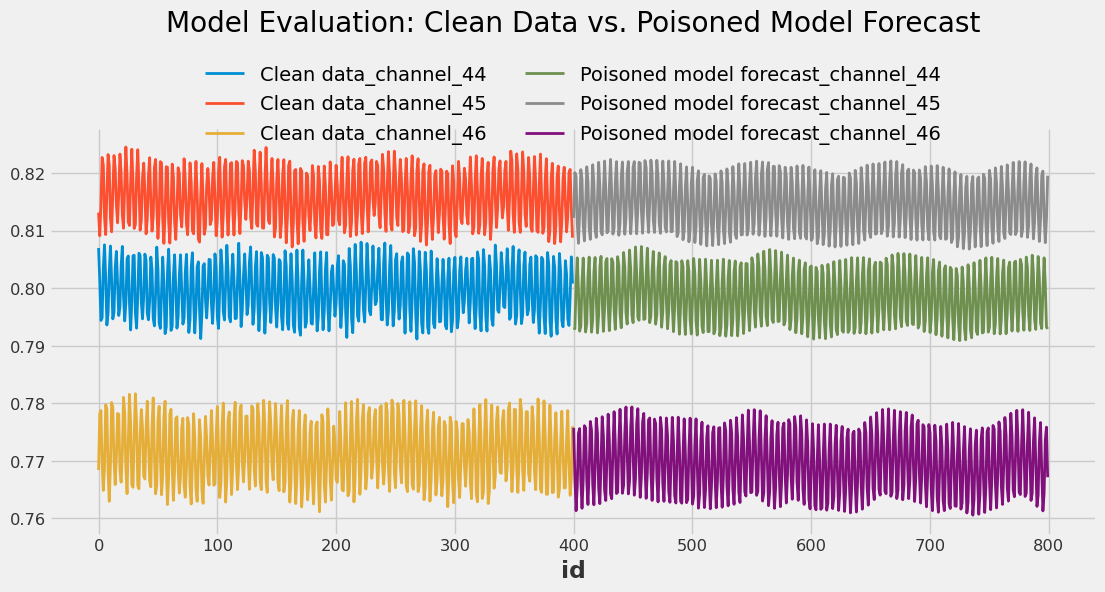

In [13]:
# 1) Plot the clean series and grab the Axes
ax = train_data_series[:400].plot(label="Clean data")

# 2) Plot the forecast on that same Axes
pred_poisoned = poisoned_model.predict(400, series=train_data_series[:400])
pred_poisoned.plot(label="Poisoned model forecast", ax=ax)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)
ax.set_title("Model Evaluation: Clean Data vs. Poisoned Model Forecast", pad=70)

plt.show()


### Injected Input

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 83.42it/s]


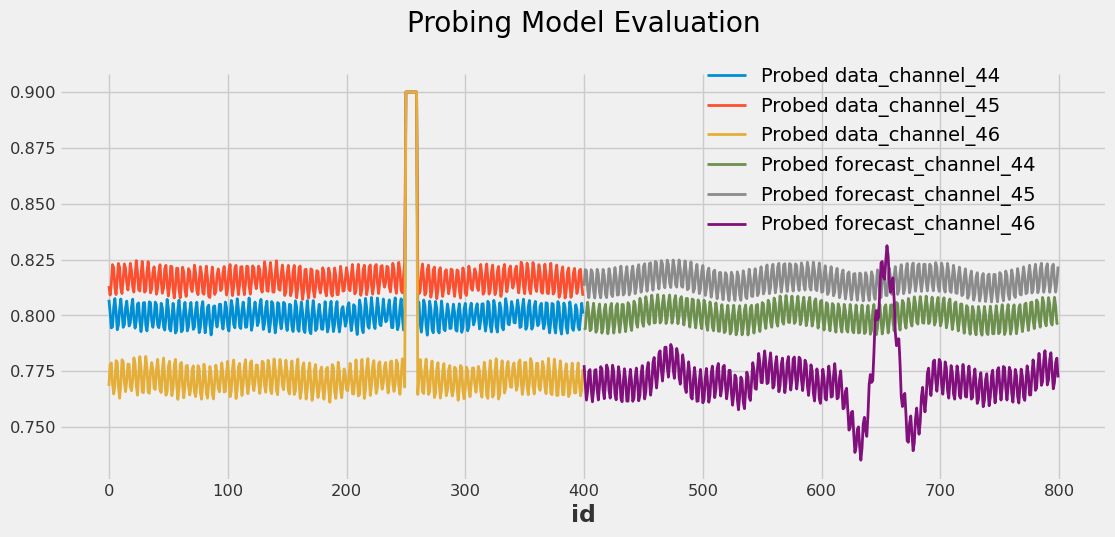

In [14]:
# 1) Copy the clean DataFrame and inject a spike between indices 250–259
train_data_probed_df = train_data_df.copy(deep=True)
for channel in ["channel_44", "channel_45", "channel_46"]:
    train_data_probed_df[channel].iloc[250:260] = 0.9

# 2) Convert the probed DataFrame to a Darts TimeSeries (float32)
val_spike = (
    TimeSeries.from_dataframe(train_data_probed_df)
    .astype(np.float32)
)

# 3) Plot the probed data (first 400 timesteps)
ax = val_spike[:400].plot(label="Probed data")

# 4) Generate and plot the model’s forecast on the probed series
pred_spike = poisoned_model.predict(
    n=400,
    series=val_spike[:400]
)
pred_spike.plot(label="Probed forecast", ax=ax)

# 5) Finalize the visualization
ax.legend(loc='upper right', bbox_to_anchor=(0.95, 1.06))
ax.set_title("Probing Model Evaluation", pad=30)
plt.show()


## Probing the Model with a Spike

We injected a sharp **spike** (🔺) into channels _44_, _45_ and _46_ between time‐steps 250–259, and then compared:

| Scenario      | Observation                                                                                 |
|---------------|---------------------------------------------------------------------------------------------|
| **Clean**     | The poisoned model’s forecast remains smooth and stable (no major deviations).             |
| **Probed**    | 🚨 Right after the spike, the model’s forecast **shifts dramatically**—especially in channel 46!  |

### What’s going on? 🤔

1. **Spike Injection**  
   We temporarily boosted the value to **0.9** in all three channels.  
2. **Model Sensitivity**  
   - Channels 44 & 45: small shift in mean and oscillation amplitude.  
   - Channel 46: large deviation (notice the big bump and oscillation changes around t≈650). 😱  
3. **Delayed Effect**  
   The forecast beyond the training window (t>400) shows that a **local perturbation** can cause **long‐range distortions** in predictions.  
4. **Key Takeaway**  
   A brief, targeted anomaly can significantly distort a poisoned model’s forecasts—and by systematically probing some of the poisoned models with such spikes, we can uncover the very trigger that was used to poison it. This simple probing approach therefore not only exposes model vulnerabilities but also reveals hidden poisoning strategies. 🕵️‍♂️🛡️
